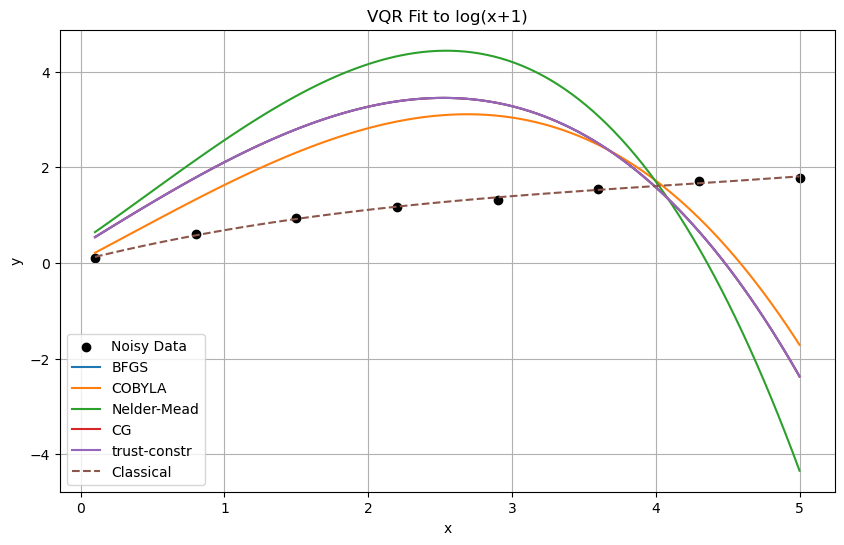

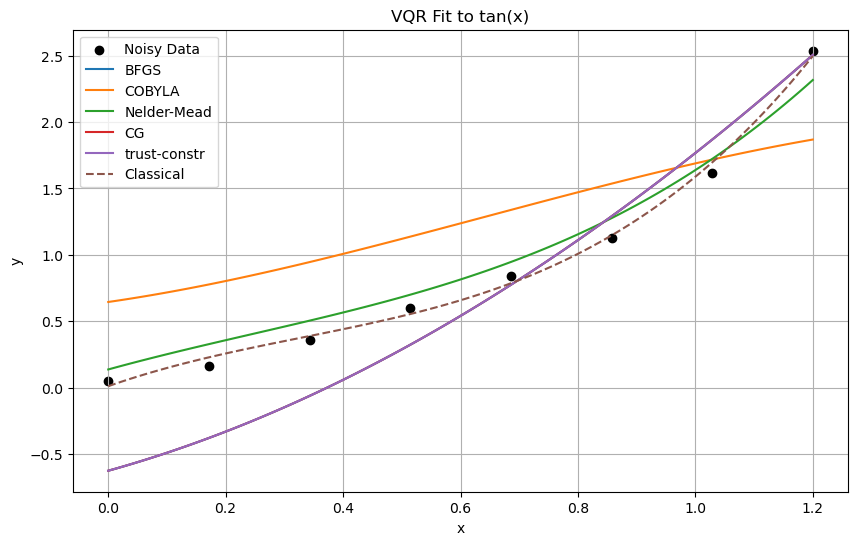

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from scipy.optimize import minimize

# Inner product using quantum circuit
def inner_prod(vec1, vec2):
    if len(vec1) != len(vec2):
        raise ValueError("Vectors must be the same length")

    N = len(vec1)
    nqubits = math.ceil(np.log2(N))
    
    vec = np.concatenate((vec1, vec2)) / np.sqrt(2)
    
    circ = QuantumCircuit(nqubits + 1)
    circ.initialize(vec, range(nqubits + 1))
    circ.h(nqubits)

    state = Statevector.from_instruction(circ)
    real_amps = np.real(state.data)

    m_sum = sum(real_amps[l]**2 for l in range(N))
    return 2 * m_sum - 1

# Polynomial ansatz cost function
def calculate_cost_function_n(parameters):
    ansatz = parameters[0] * np.ones_like(x)
    for i in range(1, len(parameters)):
        ansatz += parameters[i] * x**i
        
    ansatz_norm = np.linalg.norm(ansatz)
    ansatz_unit = ansatz / ansatz_norm
    y_ansatz = ansatz_norm / ynorm * inner_prod(y, ansatz_unit)

    return (1 - y_ansatz)**2

# Generate data from function with noise
def generate_data(func, x_range, noise=0.05):
    x = np.linspace(*x_range, N)
    y = func(x) + np.random.uniform(-noise, noise, N)
    return x, y

# Run multiple optimizers on cost function
def run_optimizers(cost_fn, x0):
    methods = ["BFGS", "COBYLA", "Nelder-Mead", "CG", "trust-constr"]
    results = {}
    for method in methods:
        result = minimize(cost_fn, x0=x0, method=method,
                          options={'maxiter': 200}, tol=1e-6)
        results[method] = result
    return results

# Evaluate a polynomial
def evaluate_fit(xfit, coeffs):
    yfit = np.zeros_like(xfit)
    for i, a in enumerate(coeffs):
        yfit += a * xfit**i
    return yfit

# Full VQR run and plotting for one function
def run_vqr_for_function(func, label, x_range):
    global x, y, ynorm

    x, y = generate_data(func, x_range)
    ynorm = np.linalg.norm(y)
    y = y / ynorm

    x0 = [random.uniform(0, 2) for _ in range(order + 1)]
    results = run_optimizers(calculate_cost_function_n, x0)

    xfit = np.linspace(*x_range, 100)
    
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y * ynorm, label="Noisy Data", color='black')

    for method, result in results.items():
        coeffs = result.x
        yfit = evaluate_fit(xfit, coeffs)
        plt.plot(xfit, yfit, label=method)

    classical_fit = np.polyfit(x, y * ynorm, order)[::-1]
    y_classical = evaluate_fit(xfit, classical_fit)
    plt.plot(xfit, y_classical, label="Classical", linestyle='dashed')

    plt.title(f"VQR Fit to {label}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()

# Global config
order = 3
N = 8

# Run VQR for log(x+1)
run_vqr_for_function(lambda x: np.log(x + 1), "log(x+1)", x_range=(0.1, 5))

# Run VQR for tan(x) (avoid vertical asymptotes)
run_vqr_for_function(lambda x: np.tan(x), "tan(x)", x_range=(0, 1.2))
